In [ ]:
!nvidia-smi

Wed Jun 17 13:39:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install ultralytics -q

import ultralytics
ultralytics.checks()

Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.1/112.6 GB disk)


In [ ]:
from ultralytics.utils.downloads import download

  # Ultralytics brain-tumor veri setini indir ve aç
download("https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip", dir="datasets")

print("\nVeri seti indirildi!")
!ls datasets/brain-tumor

Unzipping datasets/brain-tumor.zip to /content/datasets/brain-tumor...: 100% ━━━━━━━━━━━━ 2225/2225 5.0Kfiles/s 0.4s

Veri seti indirildi!
brain-tumor.yaml  images  labels  LICENSE.txt


In [ ]:
import os

base = "datasets/brain-tumor"

  # Klasör yapısını göster
print("=== Klasör yapısı ===")
for root, dirs, files in os.walk(base):
      level = root.replace(base, "").count(os.sep)
      indent = "  " * level
      print(f"{indent}{os.path.basename(root)}/  ({len(files)} dosya)")
      if level > 1:  # çok derine inme
          continue

  # Görüntü sayıları
print("\n=== Görüntü sayıları ===")
for split in ["train", "valid"]:
      img_path = os.path.join(base, "images", split)
      if os.path.exists(img_path):
          n = len([f for f in os.listdir(img_path) if f.endswith((".jpg", ".png", ".jpeg"))])
          print(f"{split}: {n} görüntü")

=== Klasör yapısı ===
brain-tumor/  (2 dosya)
  labels/  (0 dosya)
    val/  (223 dosya)
    train/  (878 dosya)
  images/  (0 dosya)
    val/  (223 dosya)
    train/  (893 dosya)

=== Görüntü sayıları ===
train: 893 görüntü


In [ ]:
with open("datasets/brain-tumor/brain-tumor.yaml", "r") as f:
 print(f.read())

# Ultralytics 🚀 AGPL-3.0 License - https://ultralytics.com/license

# Brain-tumor dataset by Ultralytics
# Documentation: https://docs.ultralytics.com/datasets/detect/brain-tumor/
# Example usage: yolo train data=brain-tumor.yaml
# parent
# ├── ultralytics
# └── datasets
#     └── brain-tumor ← downloads here (4.21 MB)

# Train/val/test sets as 1) dir: path/to/imgs, 2) file: path/to/imgs.txt, or 3) list: [path/to/imgs1, path/to/imgs2, ..]
path: brain-tumor # dataset root dir
train: images/train # train images (relative to 'path') 893 images
val: images/val # val images (relative to 'path') 223 images
test: # test images (relative to 'path')

# Classes
names:
  0: negative
  1: positive

# Download script/URL (optional)
download: https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip


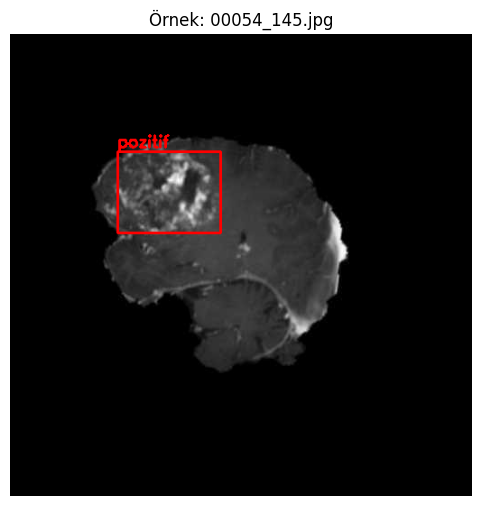

In [ ]:
import matplotlib.pyplot as plt
import cv2
import glob

  # Bir eğitim görüntüsü ve etiketini al
img_files = sorted(glob.glob("datasets/brain-tumor/images/train/*.jpg"))
sample_img = img_files[0]
sample_lbl = sample_img.replace("/images/", "/labels/").replace(".jpg", ".txt")

img = cv2.imread(sample_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

  # YOLO etiket formatı: class x_center y_center width height (normalize)
with open(sample_lbl) as f:
      for line in f:
          cls, xc, yc, bw, bh = map(float, line.split())
          x1 = int((xc - bw/2) * w); y1 = int((yc - bh/2) * h)
          x2 = int((xc + bw/2) * w); y2 = int((yc + bh/2) * h)
          cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)
          cv2.putText(img, ["negatif","pozitif"][int(cls)], (x1, y1-5),
                      cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,0), 2)

plt.figure(figsize=(6,6))
plt.imshow(img); plt.axis("off")
plt.title(f"Örnek: {os.path.basename(sample_img)}")
plt.show()

In [ ]:
from ultralytics import YOLO

  # Önceden eğitilmiş YOLOv8 nano modelini yükle (transfer learning)
model = YOLO("yolov8n.pt")

  # Eğitim
results = model.train(
      data="datasets/brain-tumor/brain-tumor.yaml",
      epochs=50,
      imgsz=640,
      batch=16,
      patience=15,          # 15 epoch iyileşme olmazsa erken durdur
      optimizer="auto",     # YOLO otomatik en iyi optimizer'ı seçer
      seed=42,              # tekrarlanabilirlik
      project="brain_tumor",
      name="yolov8n_50ep",
      plots=True            # eğitim grafiklerini otomatik üretir
  )

New https://pypi.org/project/ultralytics/8.4.70 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/brain-tumor/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

In [ ]:
 # İyileştirilmiş model — daha büyük mimari + daha uzun eğitim
model_s = YOLO("yolov8s.pt")

results_s = model_s.train(
      data="datasets/brain-tumor/brain-tumor.yaml",
      epochs=100,
      imgsz=640,
      batch=16,
      patience=40,          # erken durmayı gevşet
      cos_lr=True,          # kosinüs öğrenme hızı
      optimizer="auto",
      seed=42,
      project="brain_tumor",
      name="yolov8s_100ep",
      plots=True
  )

New https://pypi.org/project/ultralytics/8.4.70 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=datasets/brain-tumor/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0

best.pt var mı?: True
Ultralytics 8.4.69 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 256.5±149.7 MB/s, size: 3.6 KB)
val: Scanning /content/datasets/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 103.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 3.4it/s 4.1s
                   all        223        241      0.459      0.775       0.49       0.36
              negative        142        154      0.549      0.721      0.576       0.43
              positive         81         87      0.368       0.83      0.403       0.29
Speed: 3.6ms preprocess, 5.1ms inference, 0.0ms loss, 1.9ms postprocess per image
Results saved to /content/runs/detect/val

===== ÖZET METRİKLER =====
mAP@0.5      : 0.4897
mAP@0.5:0.95 : 0.3600

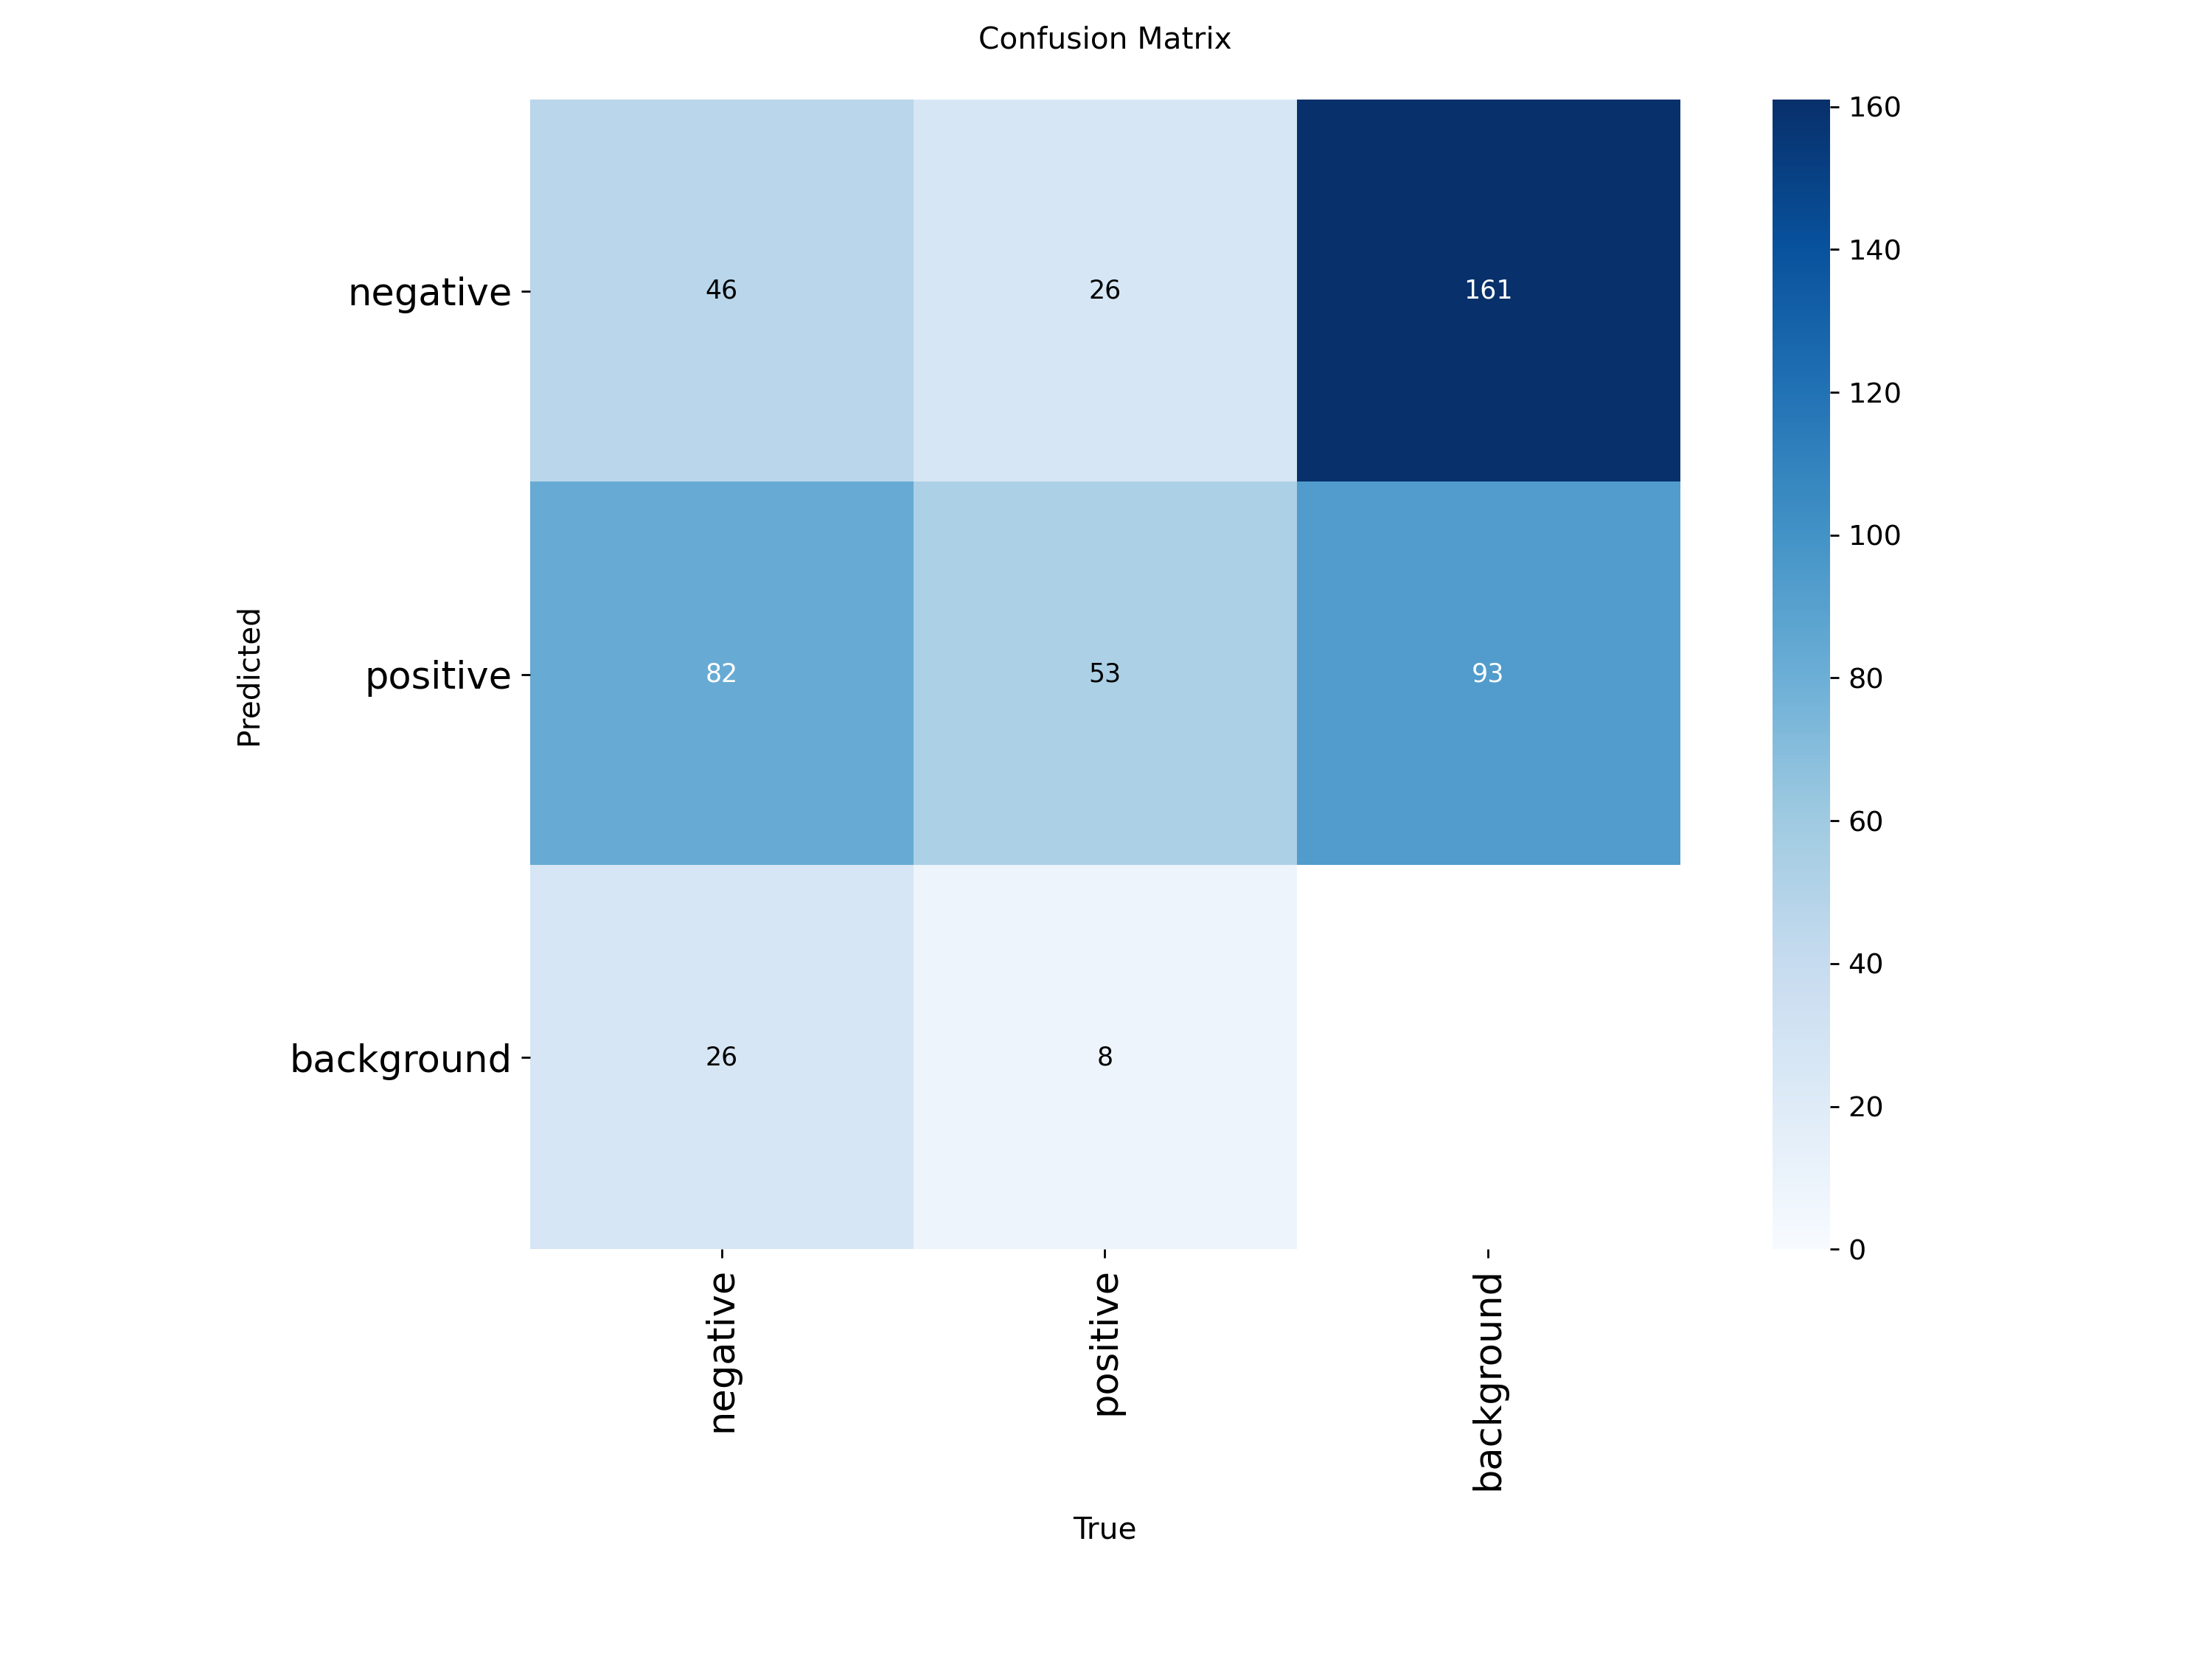


### confusion_matrix_normalized.png


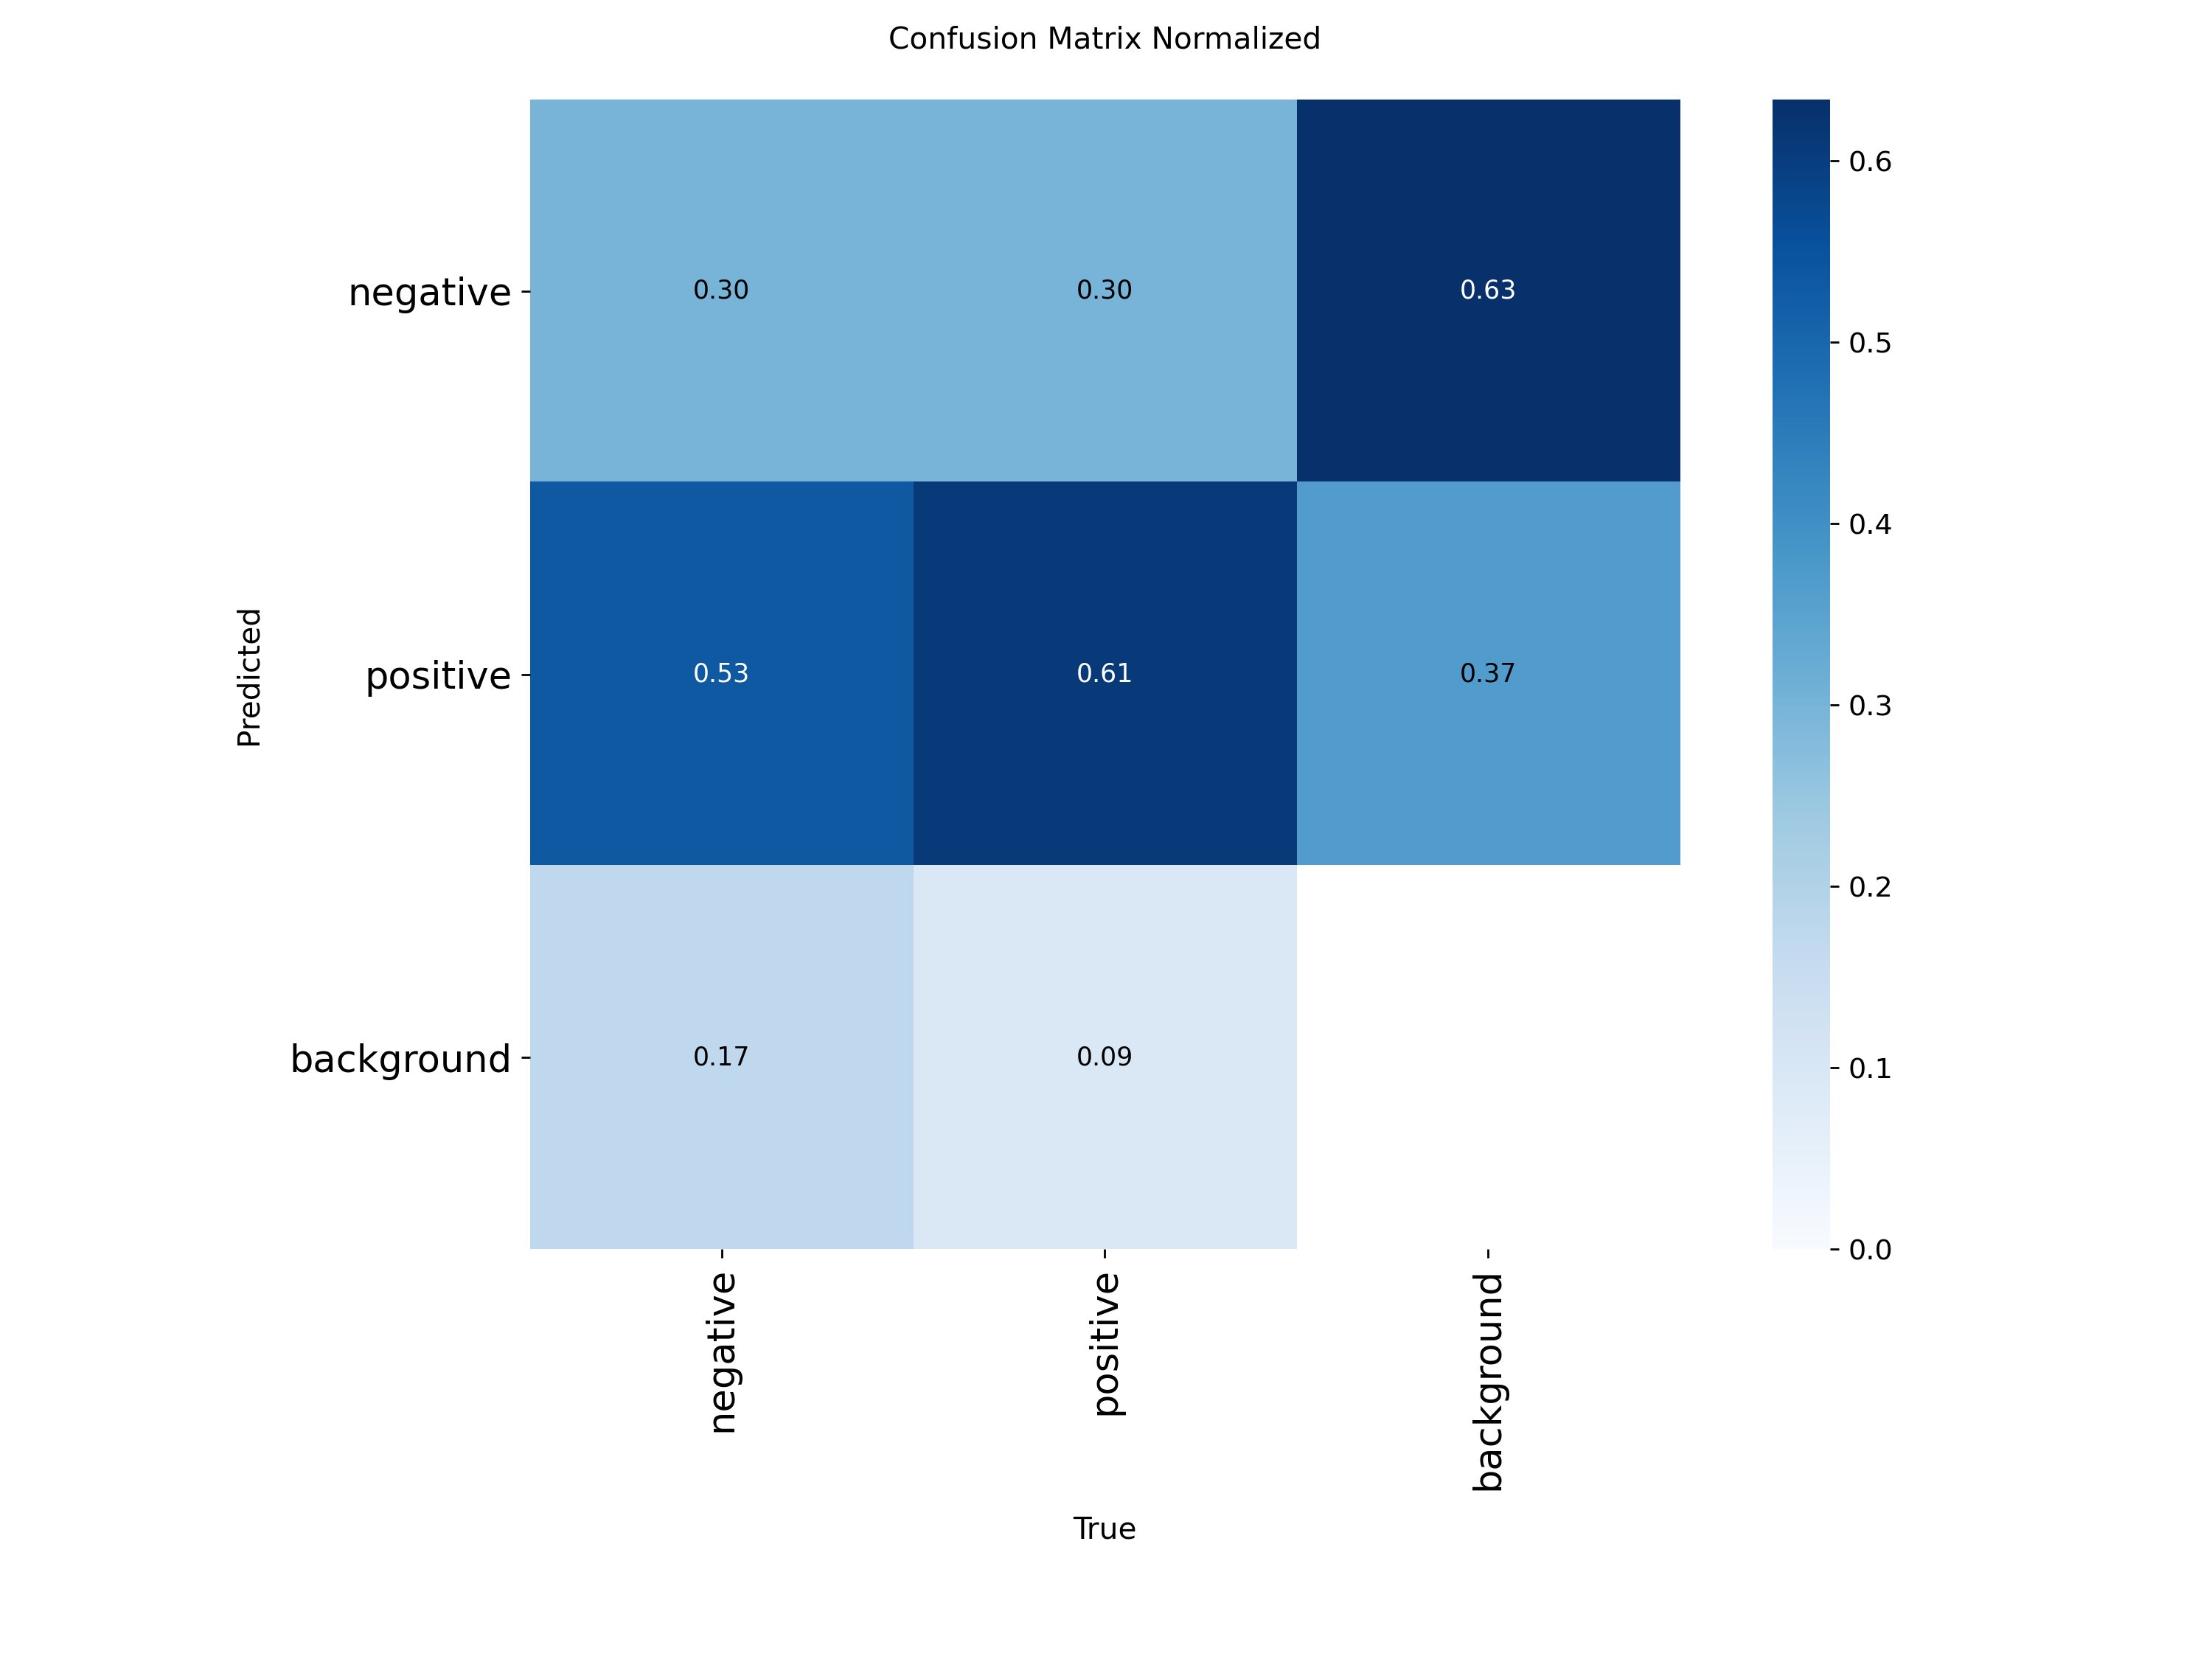


### results.png


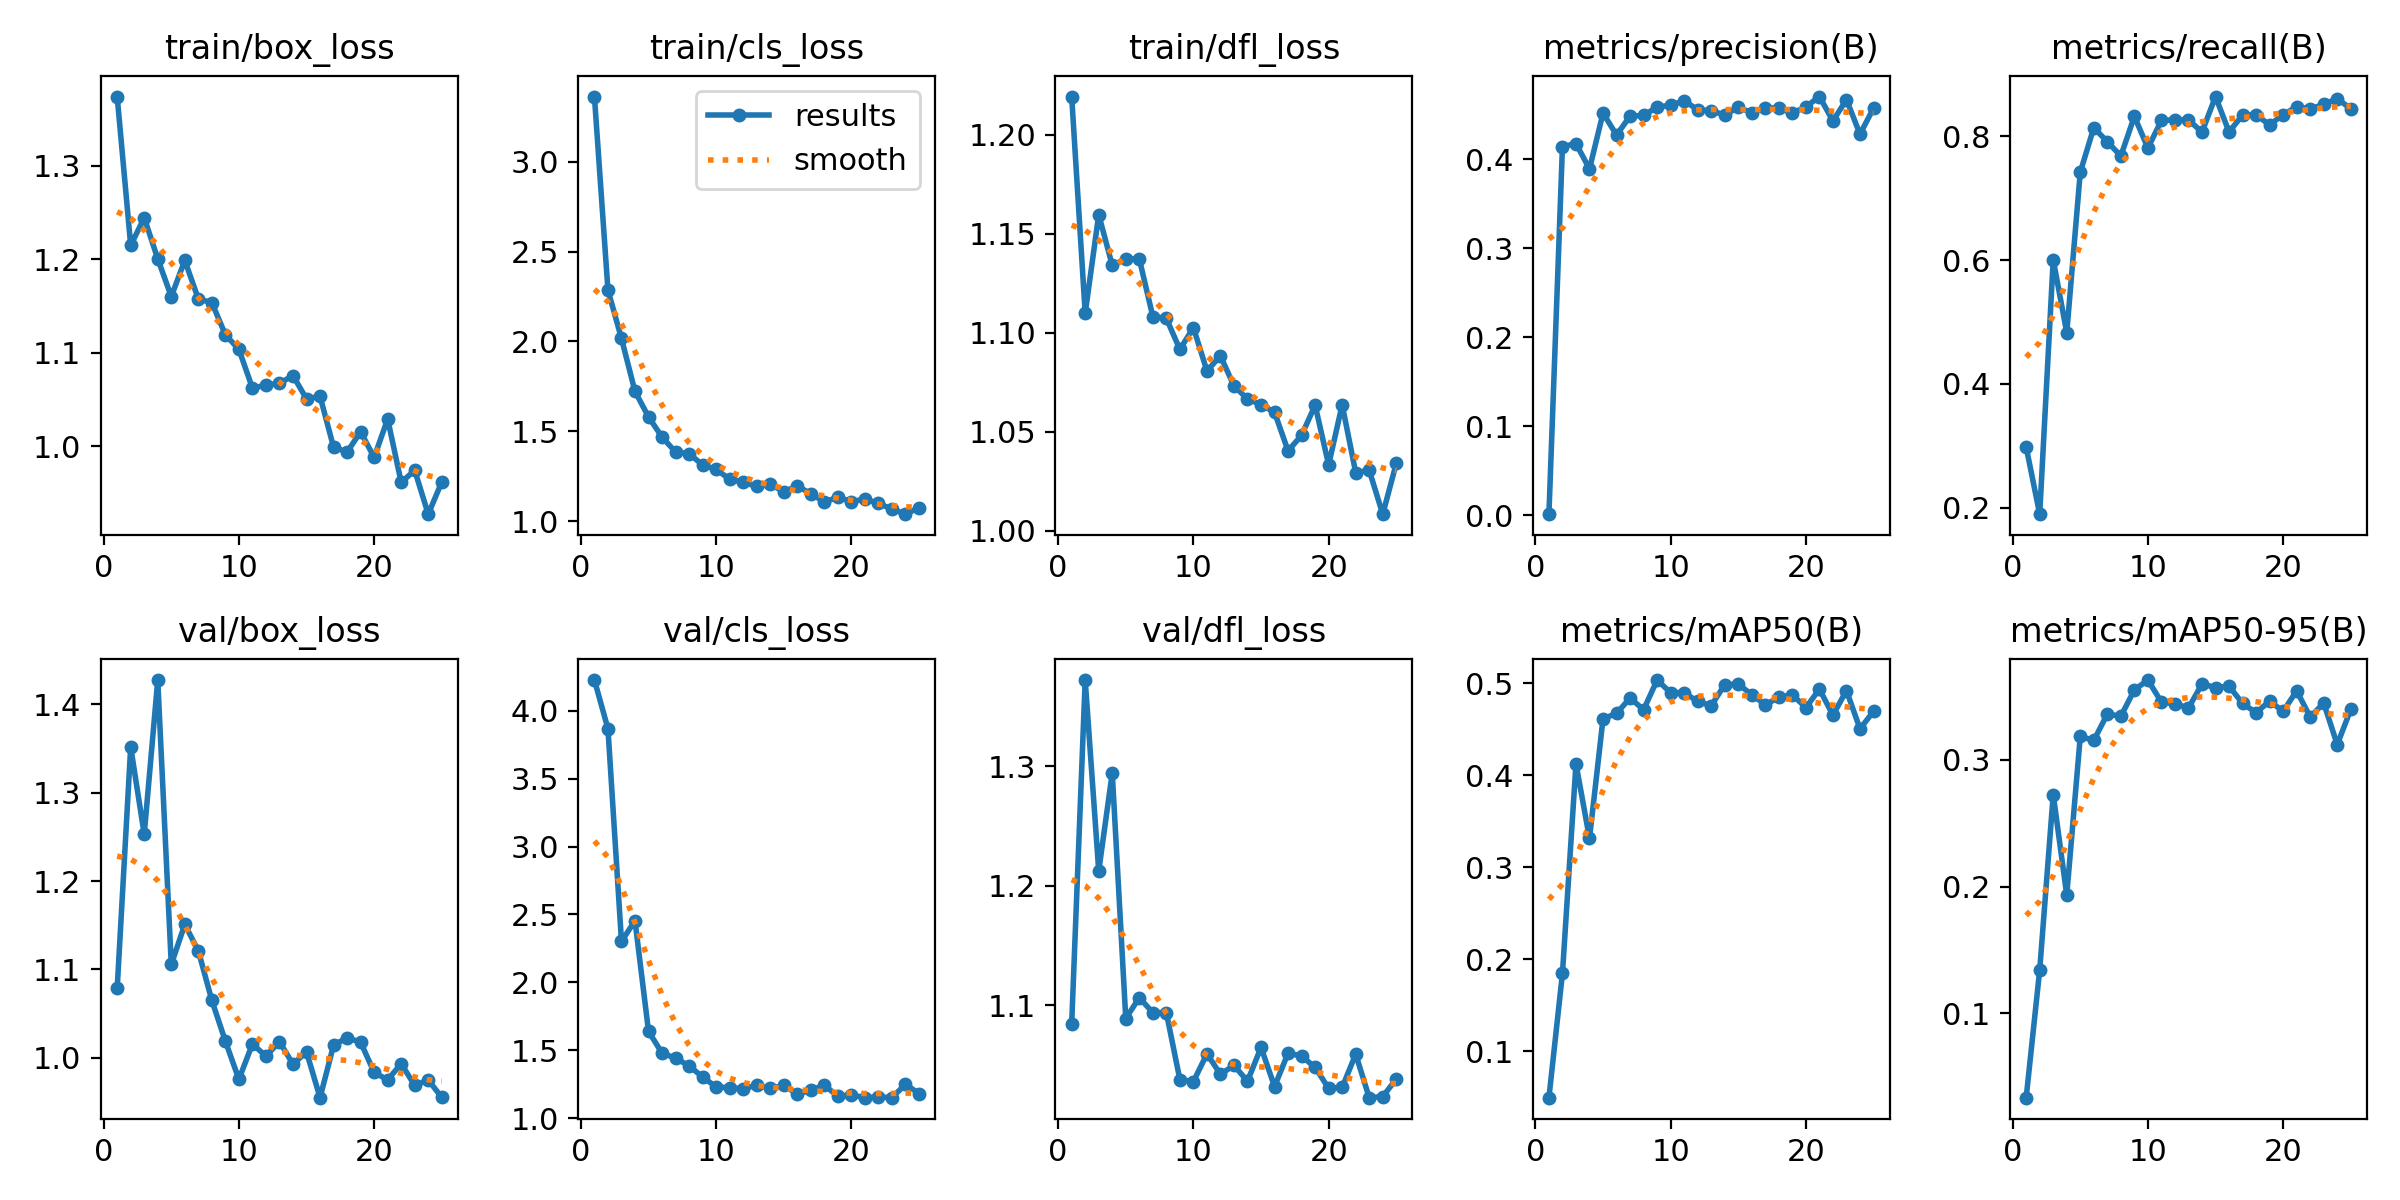

In [ ]:
from ultralytics import YOLO
from IPython.display import Image, display
import os

  # DOĞRU yol: runs/detect/ öneki ile
run_dir = "runs/detect/brain_tumor/yolov8n_50ep"
best_path = os.path.join(run_dir, "weights/best.pt")

  # Kontrol: yol gerçekten var mı?
print("best.pt var mı?:", os.path.exists(best_path))

final_model = YOLO(best_path)

  # Validasyon seti üzerinde detaylı değerlendirme
metrics = final_model.val(data="datasets/brain-tumor/brain-tumor.yaml", split="val")

print("\n===== ÖZET METRİKLER =====")
print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

  # Otomatik üretilen grafikleri göster
for img in ["confusion_matrix.png", "confusion_matrix_normalized.png",
              "results.png", "PR_curve.png", "P_curve.png", "R_curve.png"]:
      p = os.path.join(run_dir, img)
      if os.path.exists(p):
          print(f"\n### {img}")
          display(Image(filename=p))

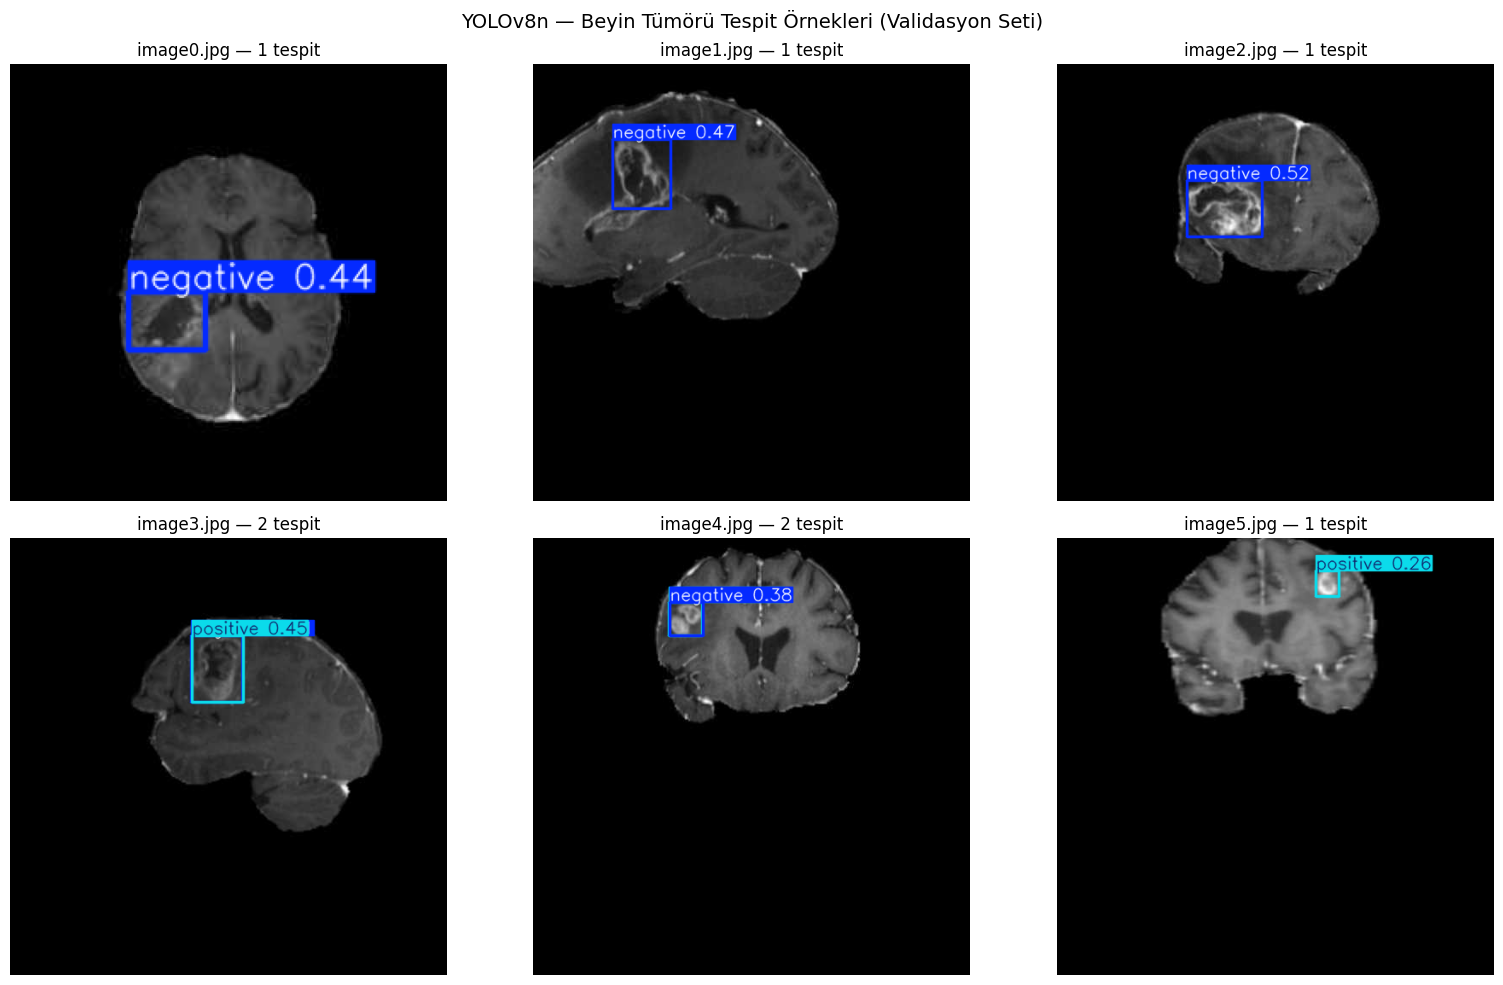

Kaydedildi: ornek_tahminler.png


In [ ]:
import glob, random
import matplotlib.pyplot as plt
import cv2

  # Validasyon setinden 6 rastgele görüntü seç
val_images = sorted(glob.glob("datasets/brain-tumor/images/val/*.jpg"))
random.seed(42)
samples = random.sample(val_images, 6)

  # Tahmin yap (conf=0.25 eşiği)
results = final_model.predict(samples, conf=0.25, imgsz=640, verbose=False)

  # 2x3 ızgarada göster
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, res in zip(axes.flat, results):
      annotated = res.plot()  # kutuları çizilmiş görüntü (BGR)
      annotated = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
      ax.imshow(annotated)
      ax.axis("off")
      n = len(res.boxes)
      ax.set_title(f"{os.path.basename(res.path)} — {n} tespit")

plt.suptitle("YOLOv8n — Beyin Tümörü Tespit Örnekleri (Validasyon Seti)", fontsize=14)
plt.tight_layout()
plt.savefig("ornek_tahminler.png", dpi=120, bbox_inches="tight")
plt.show()
print("Kaydedildi: ornek_tahminler.png")

In [2]:
import os
print("Model duruyor mu?:", os.path.exists("runs/detect/brain_tumor/yolov8n_50ep/weights/best.pt"))
!ls runs/detect/brain_tumor/ 2>/dev/null || echo "KLASÖR YOK - oturum sıfırlanmış"

Model duruyor mu?: False
KLASÖR YOK - oturum sıfırlanmış


In [3]:
!pip install ultralytics -q

from google.colab import drive
drive.mount('/content/drive')

import os
backup = "/content/drive/MyDrive/beyin_tumoru_final"
os.makedirs(backup, exist_ok=True)
print("✅ Drive bağlandı. Yedek klasörü:", backup)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 74.2 MB/s eta 0:00:00
Mounted at /content/drive
✅ Drive bağlandı. Yedek klasörü: /content/drive/MyDrive/beyin_tumoru_final


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Unzipping datasets/brain-tumor.zip to /content/datasets/brain-tumor...: 100% ━━━━━━━━━━━━ 2225/2225 5.3Kfiles/s 0.4s
Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/brain-tumor/brain-tumor.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=F

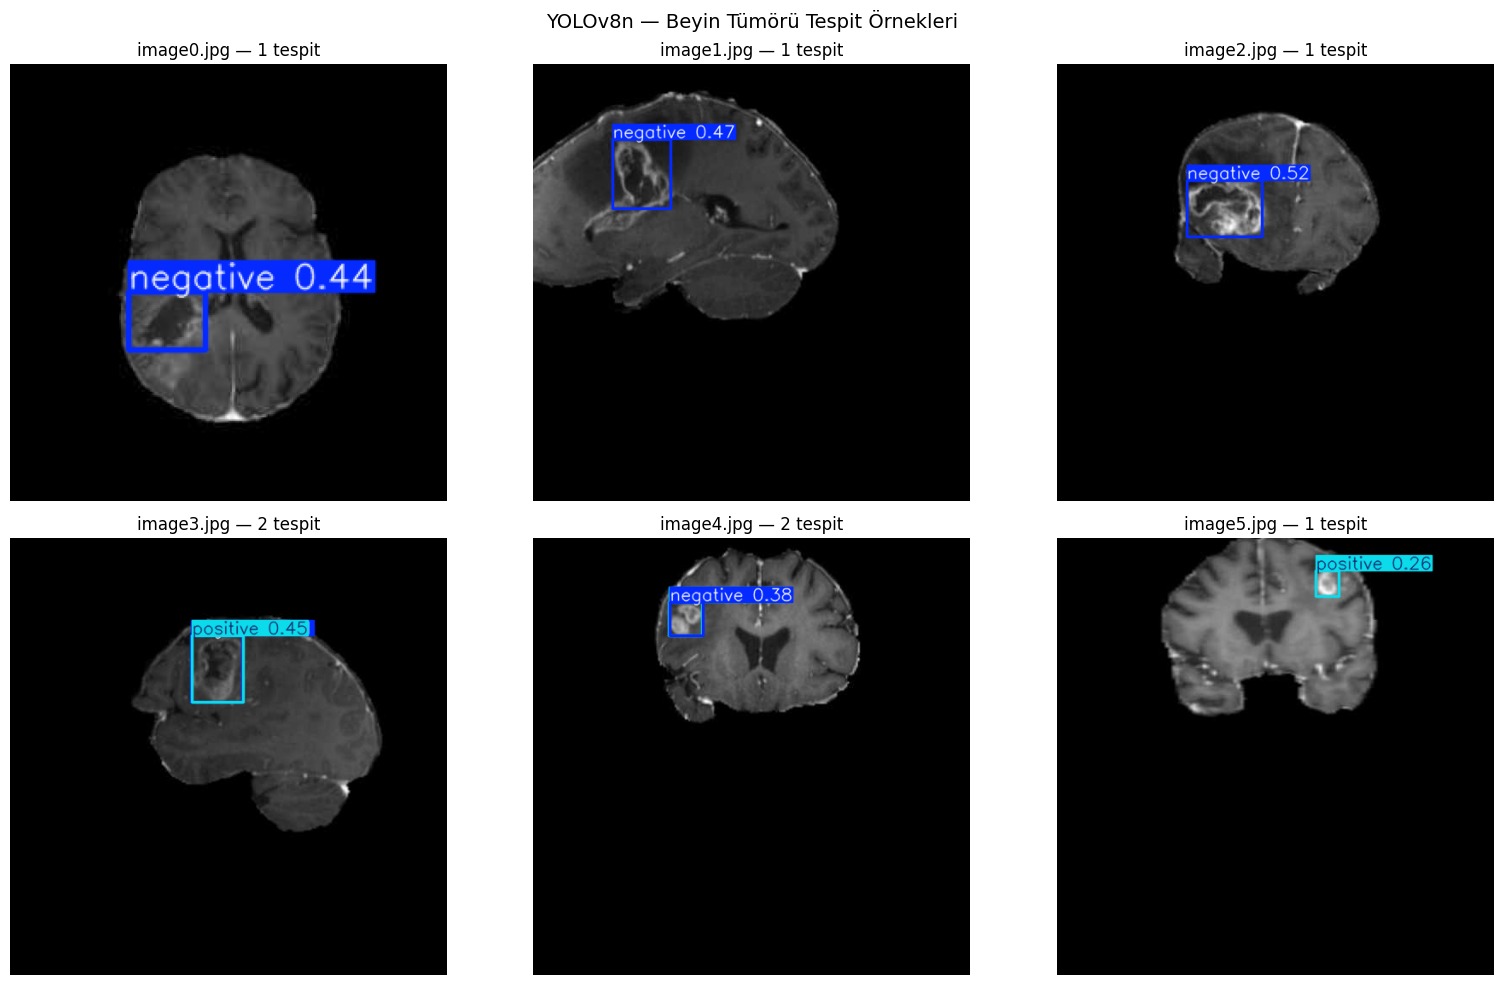


✅✅ Her şey Drive'a yedeklendi: /content/drive/MyDrive/beyin_tumoru_final
args.yaml			 labels.jpg	      val_batch0_labels.jpg
BoxF1_curve.png			 ornek_tahminler.png  val_batch0_pred.jpg
BoxP_curve.png			 results.csv	      val_batch1_labels.jpg
BoxPR_curve.png			 results.png	      val_batch1_pred.jpg
BoxR_curve.png			 train_batch0.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch1.jpg     val_batch2_pred.jpg
confusion_matrix.png		 train_batch2.jpg     weights


In [4]:
from ultralytics import YOLO
from ultralytics.utils.downloads import download
import glob, random, cv2, os
import matplotlib.pyplot as plt
from IPython.display import Image, display

  # 1) Veri setini indir
download("https://github.com/ultralytics/assets/releases/download/v0.0.0/brain-tumor.zip", dir="datasets")

  # 2) Eğitim (yolov8n, final model)
model = YOLO("yolov8n.pt")
model.train(
      data="datasets/brain-tumor/brain-tumor.yaml",
      epochs=50, imgsz=640, batch=16, patience=15,
      optimizer="auto", seed=42,
      project="brain_tumor", name="yolov8n_50ep", plots=True
  )

run_dir = "runs/detect/brain_tumor/yolov8n_50ep"
best = YOLO(f"{run_dir}/weights/best.pt")

  # 3) Değerlendirme
metrics = best.val(data="datasets/brain-tumor/brain-tumor.yaml", split="val")
print(f"\nmAP50={metrics.box.map50:.4f}  mAP50-95={metrics.box.map:.4f}  P={metrics.box.mp:.4f}  R={metrics.box.mr:.4f}")

  # 4) Örnek tahmin görselleştirme
val_images = sorted(glob.glob("datasets/brain-tumor/images/val/*.jpg"))
random.seed(42)
samples = random.sample(val_images, 6)
results = best.predict(samples, conf=0.25, imgsz=640, verbose=False)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, res in zip(axes.flat, results):
      ax.imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)); ax.axis("off")
      ax.set_title(f"{os.path.basename(res.path)} — {len(res.boxes)} tespit")
plt.suptitle("YOLOv8n — Beyin Tümörü Tespit Örnekleri", fontsize=14)
plt.tight_layout(); plt.savefig(f"{run_dir}/ornek_tahminler.png", dpi=120, bbox_inches="tight"); plt.show()

  # 5) HEMEN Drive'a yedekle
!cp -r "{run_dir}" "{backup}/"
print("\n✅✅ Her şey Drive'a yedeklendi:", backup)
!ls "{backup}/yolov8n_50ep"